In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(
    style="darkgrid",
    palette="viridis",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (12, 6)

In [42]:
afcon = pd.read_csv("afcon2025_2026.csv",
                    on_bad_lines='skip') #skip malformed rows
                    #originally has to be 52 games, but some rows are missing thats why skip malformed rows

In [26]:
print(afcon.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          49 non-null     object 
 1   Team1                         49 non-null     object 
 2   Team2                         49 non-null     object 
 3   Score (Team1 - Team2)         49 non-null     object 
 4   FullTimeResult                49 non-null     object 
 5   Venue                         49 non-null     object 
 6   City                          49 non-null     object 
 7   Attendance                    49 non-null     int64  
 8   Goal Scorers Team 1           37 non-null     object 
 9   Goal Scorers Team 2           33 non-null     object 
 10  Team 1 Possession percentage  49 non-null     float64
 11  Team 2 Possession percentage  49 non-null     float64
 12  Team 1 Shots on Goal          49 non-null     int64  
 13  Team 2 

In [27]:
#Check for NULL
print(afcon.isna().sum())

Date                             0
Team1                            0
Team2                            0
Score (Team1 - Team2)            0
FullTimeResult                   0
Venue                            0
City                             0
Attendance                       0
Goal Scorers Team 1             12
Goal Scorers Team 2             16
Team 1 Possession percentage     0
Team 2 Possession percentage     0
Team 1 Shots on Goal             0
Team 2 Shots on Goal             0
Team 1 Shot Attempts             0
Team 2 Shot Attempts             0
Team 1 Yellow Cards              0
Team 2 Yellow Cards              0
Team 1 Corner Kicks              0
Team 2 Corner Kicks              0
Team 1 Saves                     0
Team 2 Saves                     0
dtype: int64


In [28]:
#Check those null values
afcon[['Goal Scorers Team 1','Goal Scorers Team 2']]
#We can see NaN and '\r\n\r which is messy

,Goal Scorers Team 1,Goal Scorers Team 2
0,Brahim Díaz - 55'Ayoub El Kaabi - 74',NaN
1,Lassine Sinayoko - 61',Patson Daka - 90'+2'
2,Oswin Appollis - 21'Lyle Foster - 79',Show - 35’
3,Omar Marmoush - 64'Mohamed Salah - 90'+1',Prince Dube - 20'
4,Théo Bongonda - 16'\r\n\r\n\r\n,NaN
5,"Nicolas Jackson - 40', 58'Cherif Ndiaye - 90'",NaN
6,Semi Ajayi - 36'Ademola Lookman - 52',Charles M'Mombwa - 50'
7,"Ellyes Skhiri - 10'Elias Achouri - 40', 64'",Denis Omedi - 90'+2'
8,Georgi Minoungou - 90'+5'Edmond Tapsoba - 90'+8',Marvin Anieboh - 85'
9,"Riyad Mahrez - 2', 61'Ibrahim Maza - 85'",NaN


In [29]:
#Data Cleaning
afcon["Goal Scorers Team 1"] = (
    afcon["Goal Scorers Team 1"]
    .str.replace(r"\r\n", " ", regex=True)
)

afcon["Goal Scorers Team 2"] = (
    afcon["Goal Scorers Team 2"]
    .str.replace(r"\r\n", " ", regex=True)
)
#This is unnecessary because NaN clearly shows that no goal being scored by that team
#But this code will makes it much clearer
afcon["Goal Scorers Team 1"] = afcon["Goal Scorers Team 1"].fillna("No Goals")
afcon["Goal Scorers Team 2"] = afcon["Goal Scorers Team 2"].fillna("No Goals")

In [30]:
#Cleaned
afcon[['Goal Scorers Team 1','Goal Scorers Team 2']]

,Goal Scorers Team 1,Goal Scorers Team 2
0,Brahim Díaz - 55'Ayoub El Kaabi - 74',No Goals
1,Lassine Sinayoko - 61',Patson Daka - 90'+2'
2,Oswin Appollis - 21'Lyle Foster - 79',Show - 35’
3,Omar Marmoush - 64'Mohamed Salah - 90'+1',Prince Dube - 20'
4,Théo Bongonda - 16',No Goals
5,"Nicolas Jackson - 40', 58'Cherif Ndiaye - 90'",No Goals
6,Semi Ajayi - 36'Ademola Lookman - 52',Charles M'Mombwa - 50'
7,"Ellyes Skhiri - 10'Elias Achouri - 40', 64'",Denis Omedi - 90'+2'
8,Georgi Minoungou - 90'+5'Edmond Tapsoba - 90'+8',Marvin Anieboh - 85'
9,"Riyad Mahrez - 2', 61'Ibrahim Maza - 85'",No Goals


In [31]:
afcon["Team1_Goals"] = afcon["Score (Team1 - Team2)"].str.split(" - ").str[0].astype(int)
afcon["Team2_Goals"] = afcon["Score (Team1 - Team2)"].str.split(" - ").str[1].astype(int)
afcon["Total_Goals"] = afcon["Team1_Goals"] + afcon["Team2_Goals"]

In [32]:
#Converting match stats into team1,2 performance
team_long = pd.concat([
    afcon[["Team1", "Team1_Goals", "Team 1 Shot Attempts", "Team 1 Shots on Goal",
        "Team 1 Possession percentage", "Team 1 Yellow Cards"]]
        .rename(columns={
            "Team1": "Team",
            "Team1_Goals": "Goals",
            "Team 1 Shot Attempts": "Shots",
            "Team 1 Shots on Goal": "Shots_On_Target",
            "Team 1 Possession percentage": "Possession",
            "Team 1 Yellow Cards": "Yellows"
        }),

    afcon[["Team2", "Team2_Goals", "Team 2 Shot Attempts", "Team 2 Shots on Goal",
        "Team 2 Possession percentage", "Team 2 Yellow Cards"]]
        .rename(columns={
            "Team2": "Team",
            "Team2_Goals": "Goals",
            "Team 2 Shot Attempts": "Shots",
            "Team 2 Shots on Goal": "Shots_On_Target",
            "Team 2 Possession percentage": "Possession",
            "Team 2 Yellow Cards": "Yellows"
        })
])

In [33]:
#Data Validation
# Check impossible values
(afcon["Team 1 Possession percentage"] > 100).sum()
(afcon["Team 1 Possession percentage"] < 0).sum()

# duplicates
afcon.duplicated().sum()

# Check score consistency
(afcon["Team1_Goals"] + afcon["Team2_Goals"] != afcon["Total_Goals"]).sum()

np.int64(0)

count    98.000000
mean      1.122449
std       1.018036
min       0.000000
25%       0.000000
50%       1.000000
75%       2.000000
max       3.000000
Name: Goals, dtype: float64


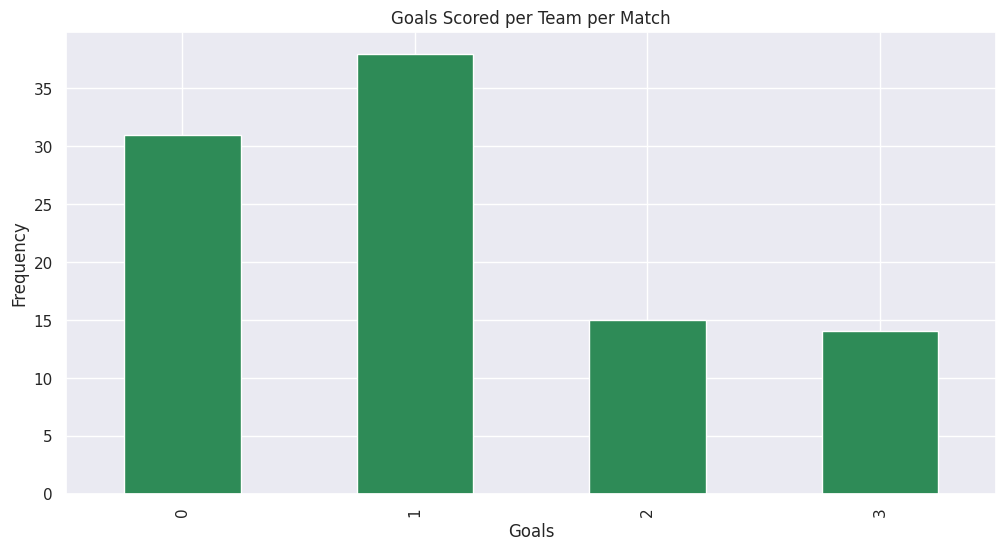

In [47]:
#Distribution of goals scored per team per match
#This analysis focus on individual team goal per team per match
#For example, if Morocco defeats Senegal 2–1, the value "2" contributes once to the distribution of Morocco.
#And 1 will be add up to Senegal, and the value keeps on adding up or stacking up on each other.
#If next match Morocco beats Tuinisia 1, then it's going to be Morocco = 2
                                                              #Morocco = 1 it's going to add up to the frequencies
#As we can see team scoring 1 goal per game happened frequently
print(team_long["Goals"].describe())
team_long["Goals"].value_counts().sort_index().plot(
    kind="bar", color="seagreen"
)
plt.title("Goals Scored per Team per Match")
plt.xlabel("Goals")
plt.ylabel("Frequency")
plt.show()


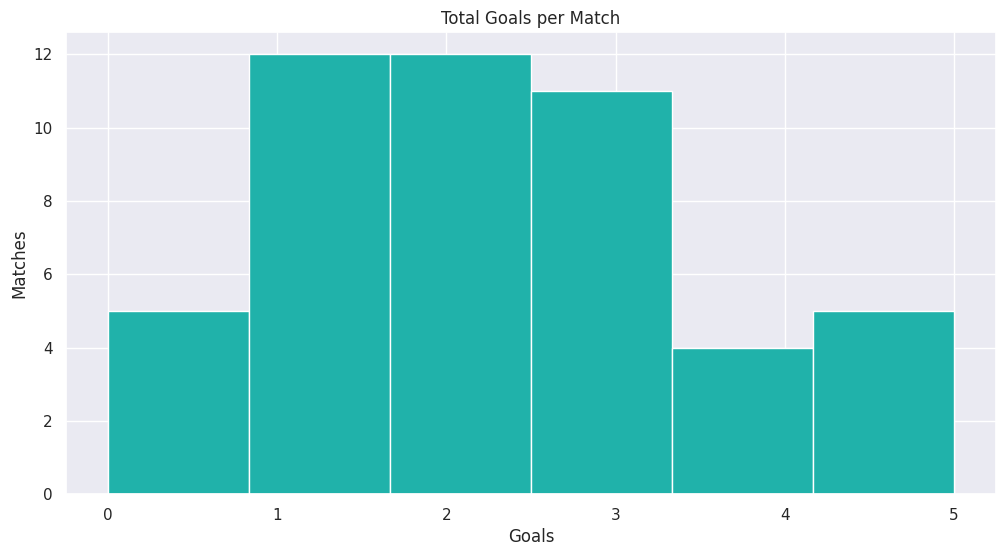

In [35]:
#The frequent of total goals per match
"""
The difference between total goals per match with total goals per team is
TOTAL GOALS PER MATCH => SUM of goals both team scored per match
TOTAL GOALS PER TEAM =>  goal that each team scored per match

"""


afcon["Total_Goals"].plot(kind="hist", bins=6, color="lightseagreen")
plt.title("Total Goals per Match")
plt.xlabel("Goals")
plt.ylabel("Matches")
plt.show()

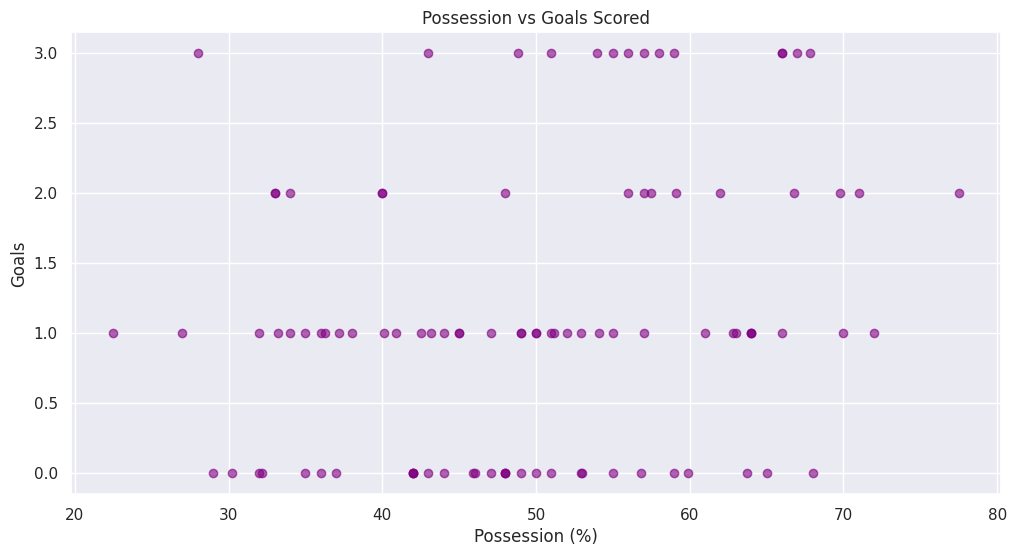

In [ ]:
#Comparing Possessions with Goal Scored in the game
#Possession doesn't win you games, but scoring did.
#This prove effiency matters more
#Like we can see team with 30% possession managed to score 3 goals. It clearly shows attacking effiency matters!
plt.scatter(team_long["Possession"], team_long["Goals"], alpha=0.6, color="purple")
plt.title("Possession vs Goals Scored")
plt.xlabel("Possession (%)")
plt.ylabel("Goals")
plt.show()


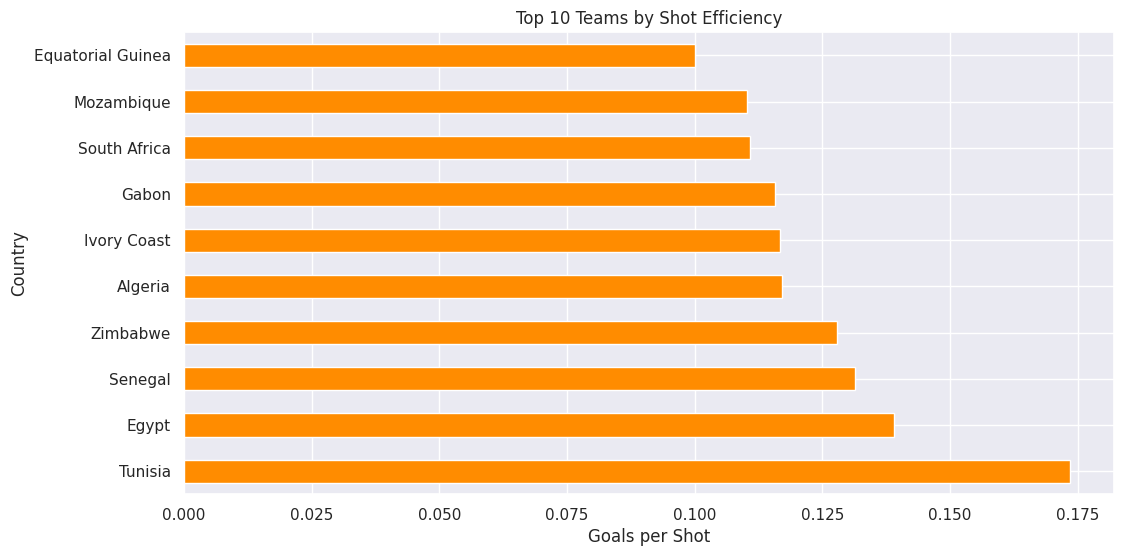

In [41]:
#Find top 10 team that have the highest shooting effectiveness rate
team_long["Shot_Efficiency"] = team_long["Goals"] / team_long["Shots"].replace(0, 1)

efficiency = (team_long.groupby("Team")["Shot_Efficiency"].mean().sort_values(ascending=False).head(10))#

efficiency.plot(kind="barh", color="darkorange")
plt.title("Top 10 Teams by Shot Efficiency")
plt.xlabel("Goals per Shot")
plt.ylabel("Country")
plt.show()

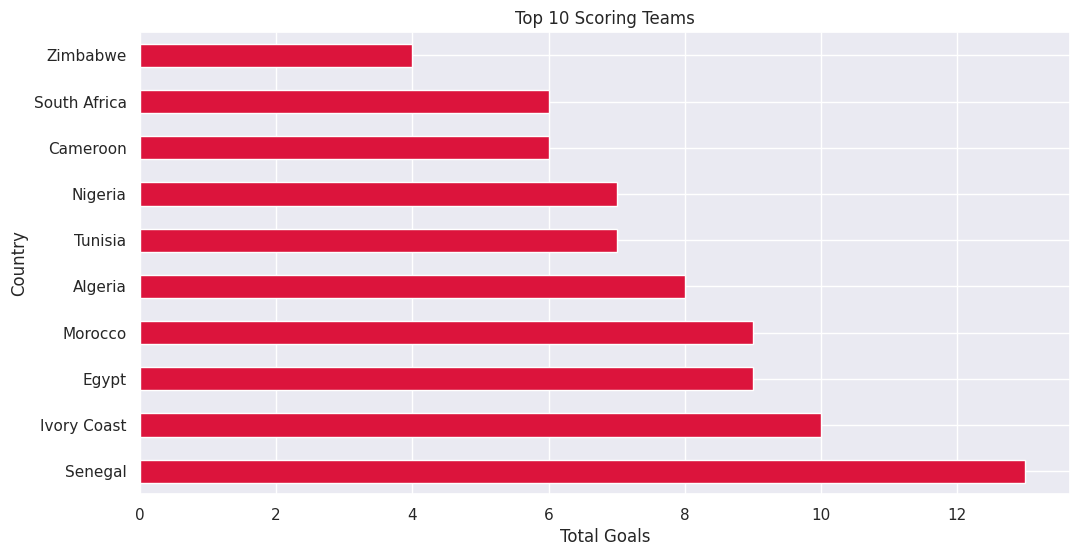

In [40]:
#Top 10 team with highest scoring
top_attack = team_long.groupby("Team")["Goals"].sum().sort_values(ascending=False).head(10)
top_attack.plot(kind="barh", color="crimson")
plt.title("Top 10 Scoring Teams")
plt.xlabel("Total Goals")
plt.ylabel("Country")
plt.show()


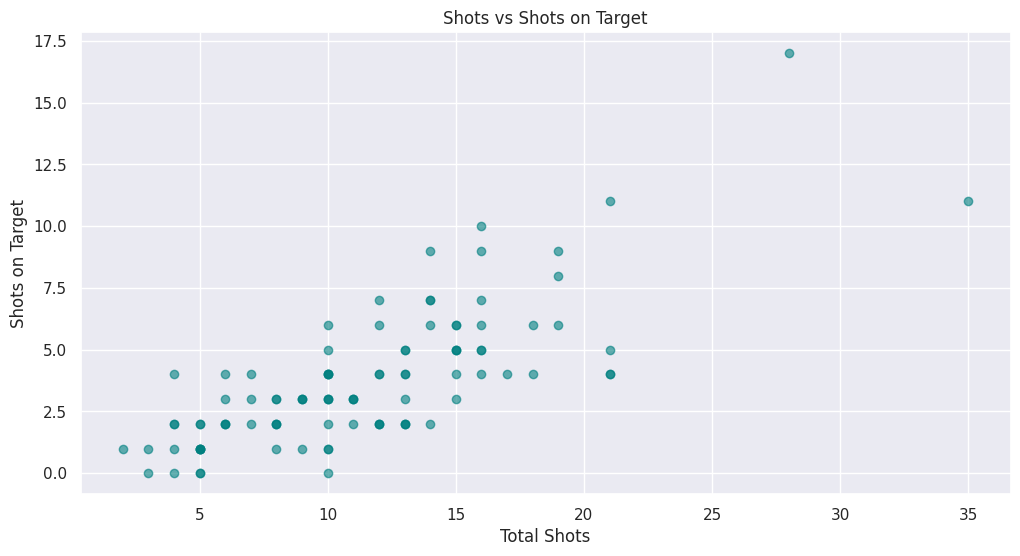

In [ ]:
#Compare Shots versus Shots on Target
plt.scatter(team_long["Shots"], team_long["Shots_On_Target"], alpha=0.6, color="teal")
plt.title("Shots vs Shots on Target")
plt.xlabel("Total Shots")
plt.ylabel("Shots on Target")
plt.show()

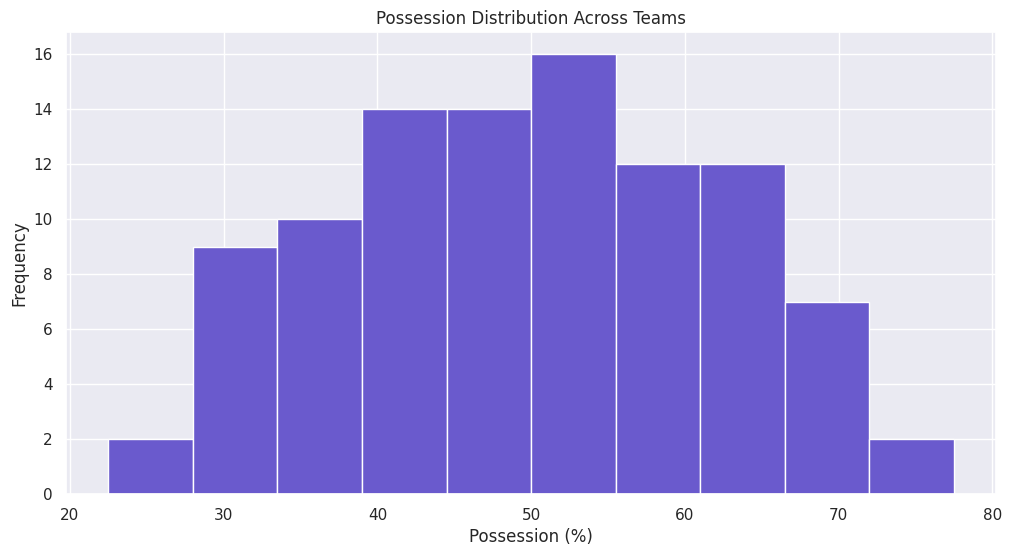

In [ ]:
#Team possession based on match
team_long["Possession"].plot(kind="hist", bins=10, color="slateblue")
plt.title("Possession Distribution Across Teams")
plt.xlabel("Possession (%)")
plt.ylabel("Frequency")
plt.show()

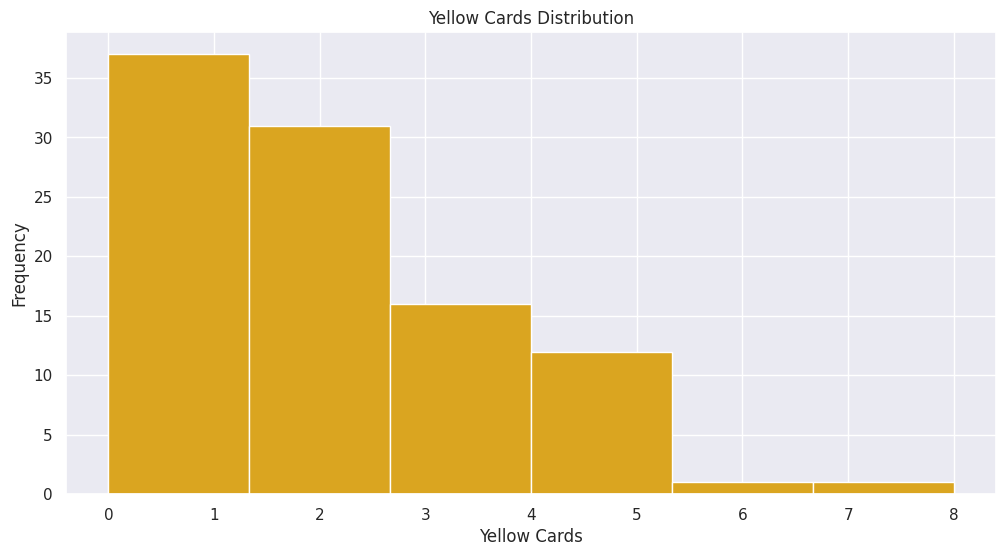

In [ ]:
team_long["Yellows"].plot(kind="hist", bins=6, color="goldenrod")
plt.title("Yellow Cards Distribution")
plt.xlabel("Yellow Cards")
plt.ylabel("Frequency")
plt.show()